# Audio Loading using Librosa

## Import Required Libraries

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# user input audio file

In [2]:

audio_path = input("upload the audio file name/path: ")

  # LOAD AUDIO FILE

In [3]:
import librosa
import librosa.display

y, sr = librosa.load(audio_path, sr=None)

print("\nAudio loaded successfully!")

print("Sampling Rate:", sr)
print("Audio Shape:", y.shape)


Audio loaded successfully!
Sampling Rate: 44100
Audio Shape: (24122,)


# AUDIO INFORMATION

In [4]:
print("\n===== AUDIO INFORMATION =====")

print("Sampling Rate:", sr)

print("Audio Shape:", y.shape)

duration = len(y) / sr

print("Duration:", round(duration, 2), "seconds")


===== AUDIO INFORMATION =====
Sampling Rate: 44100
Audio Shape: (24122,)
Duration: 0.55 seconds


# WAVEFORM PLOT

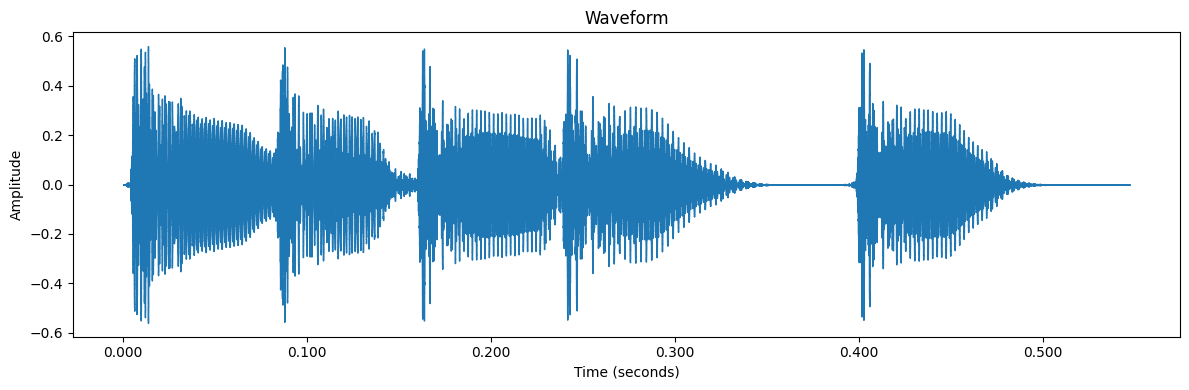

In [5]:
plt.figure(figsize=(12, 4))

librosa.display.waveshow(y, sr=sr)

plt.title("Waveform")

plt.xlabel("Time (seconds)")

plt.ylabel("Amplitude")

plt.tight_layout()

plt.show()

# STFT + SPECTROGRAM

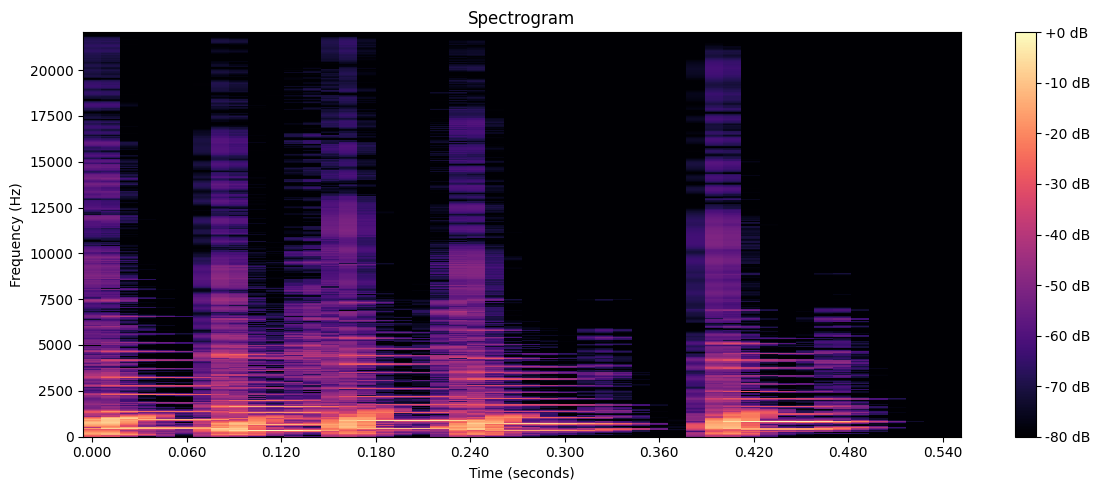

In [6]:
D = librosa.stft(y)

S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    S_db,
    sr=sr,
    x_axis='time',
    y_axis='hz'
)

plt.colorbar(format='%+2.0f dB')

plt.title("Spectrogram")

plt.xlabel("Time (seconds)")

plt.ylabel("Frequency (Hz)")

plt.tight_layout()

plt.show()


# PITCH DETECTION USING PYIN

In [7]:
hop_length = 256

fmin = librosa.note_to_hz('C2')

fmax = librosa.note_to_hz('C7')

f0, voiced_flag, voiced_probs = librosa.pyin(
    y,
    fmin=fmin,
    fmax=fmax,
    hop_length=hop_length
)

# TIME AXIS

In [8]:
times = librosa.times_like(f0)


# PITCH TRACE PLOT


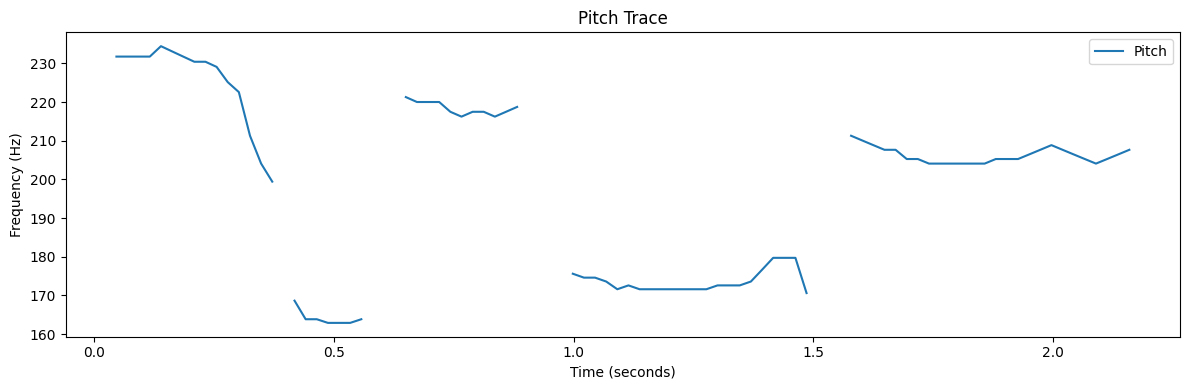

In [9]:
plt.figure(figsize=(12, 4))

plt.plot(times, f0, label="Pitch")

plt.xlabel("Time (seconds)")

plt.ylabel("Frequency (Hz)")

plt.title("Pitch Trace")

plt.legend()

plt.tight_layout()

plt.show()

# CONFIDENCE INFORMATION


In [10]:
average_confidence = np.nanmean(voiced_probs)

print("\n===== PITCH DETECTION =====")

print("Average Pitch Confidence:",
round(average_confidence, 3))


===== PITCH DETECTION =====
Average Pitch Confidence: 0.374


# PRINT SAMPLE PITCH VALUES


In [11]:
print("\n===== SAMPLE PITCH VALUES =====")

print(f0[:20])


===== SAMPLE PITCH VALUES =====
[         nan          nan 231.73942791 231.73942791 231.73942791
 231.73942791 234.43211036 233.08188076 231.73942791 230.40470702
 230.40470702 229.07767356 225.14225624 222.55627687 211.28204791
 204.08500573 199.42369775          nan 168.66611791 163.86452094]


# REMOVE NaN VALUES


In [12]:
valid_pitches = f0[~np.isnan(f0)]


# MIDI CONVERSION


In [13]:
midi_notes = librosa.hz_to_midi(valid_pitches)

print("\n===== SAMPLE MIDI NOTES =====")

print(midi_notes[:20])


===== SAMPLE MIDI NOTES =====
[57.9 57.9 57.9 57.9 58.1 58.  57.9 57.8 57.8 57.7 57.4 57.2 56.3 55.7
 55.3 52.4 51.9 51.9 51.8 51.8]


# SWARA FREQUENCY MAP


In [14]:
swara_freqs = {

    "Sa": 261.63,
    "R1": 277.18,
    "R2": 293.66,
    "G2": 311.13,
    "G3": 329.63,
    "Ma1": 349.23,
    "Ma2": 369.99,
    "Pa": 392.00,
    "Da1": 415.30,
    "Da2": 440.00,
    "Ni2": 466.16,
    "Ni3": 493.88,
    "U-Sa": 523.25
}


# STRING NOTE MAPPING


In [15]:
string_notes = {

    "Sa": 1,
    "R1": 2,
    "R2": 3,
    "G2": 4,
    "G3": 5,
    "Ma1": 6,
    "Ma2": 7,
    "Pa": 8,
    "Da1": 9,
    "Da2": 10,
    "Ni2": 11,
    "Ni3": 12,
    "U-Sa": 13
}


# FIND CLOSEST SWARA


In [16]:
def find_closest_swara(freq):

    closest = min(
        swara_freqs.items(),
        key=lambda x: abs(freq - x[1])
    )

    return closest[0]

# MAP AUDIO TO NOTES


In [17]:
detected_notes = []

for pitch in valid_pitches:

    swara = find_closest_swara(pitch)

    string_number = string_notes[swara]

    detected_notes.append(
        (pitch, swara, string_number)
    )

# PRINT FINAL DETECTED NOTES


In [18]:
print("\n===== DETECTED MUSIC NOTES =====\n")

for i, (pitch, swara, string_number) in enumerate(detected_notes[:50]):

    print(
        f"Note {i+1}: "
        f"{round(pitch,2)} Hz "
        f"→ {swara} "
        f"→ String {string_number}"
    )



===== DETECTED MUSIC NOTES =====

Note 1: 231.74 Hz → Sa → String 1
Note 2: 231.74 Hz → Sa → String 1
Note 3: 231.74 Hz → Sa → String 1
Note 4: 231.74 Hz → Sa → String 1
Note 5: 234.43 Hz → Sa → String 1
Note 6: 233.08 Hz → Sa → String 1
Note 7: 231.74 Hz → Sa → String 1
Note 8: 230.4 Hz → Sa → String 1
Note 9: 230.4 Hz → Sa → String 1
Note 10: 229.08 Hz → Sa → String 1
Note 11: 225.14 Hz → Sa → String 1
Note 12: 222.56 Hz → Sa → String 1
Note 13: 211.28 Hz → Sa → String 1
Note 14: 204.09 Hz → Sa → String 1
Note 15: 199.42 Hz → Sa → String 1
Note 16: 168.67 Hz → Sa → String 1
Note 17: 163.86 Hz → Sa → String 1
Note 18: 163.86 Hz → Sa → String 1
Note 19: 162.92 Hz → Sa → String 1
Note 20: 162.92 Hz → Sa → String 1
Note 21: 162.92 Hz → Sa → String 1
Note 22: 163.86 Hz → Sa → String 1
Note 23: 221.27 Hz → Sa → String 1
Note 24: 220.0 Hz → Sa → String 1
Note 25: 220.0 Hz → Sa → String 1
Note 26: 220.0 Hz → Sa → String 1
Note 27: 217.47 Hz → Sa → String 1
Note 28: 216.22 Hz → Sa → String 1

# OPTIONAL: SAVE RESULTS TO CSV


In [19]:
import pandas as pd

results = []

for pitch, swara, string_number in detected_notes:

    results.append({

        "pitch_hz": round(pitch, 2),

        "swara": swara,

        "string_number": string_number
    })
    
    df = pd.DataFrame(results)

df.to_csv("detected_music_notes.csv", index=False)

print("\nCSV file saved successfully!")


CSV file saved successfully!
